In [1]:
# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.9.2
Keras backend: tensorflow


In [ ]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('seitsemanVeljesta.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()#.lower()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 627246 characters
First 100 characters: 
Produced by Riikka Talonpoika, Tapio Riikonen and PG Distributed
Proofreaders





SEITSEMÄN VELJES


In [ ]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'seitsemanVeljesta_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 8000  # You can adjust this based on your needs
model_prefix = 'seitsemanVeljesta_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")


# Test tokenization
test_text = "Jukolan talo, eteläisessä Hämeessä"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Jukolan', '▁talo', ',', '▁etelä', 'isessä', '▁Häme', 'essä']
Vocabulary size: 8000


In [ ]:
seq_length = 32
pieces = sp.encode_as_ids(text)
print(f'Total tokens: {len(pieces)}')

sequences = []
for i in range(0, min(len(pieces) - seq_length, 20000)):
    sequences.append(pieces[i:i+seq_length+1])

sequences = np.array(sequences)
inputs = sequences[:, :-1]
targets = sequences[:, 1:]

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets, = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 141432
Number of sequences: 20000
Input shape: (20000, 32)
Target shape: (20000, 32)


In [ ]:
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 128
num_heads = 2
ff_dim = 256
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Helper function to create causal attention mask
def create_causal_mask(size):
    """Create a causal attention mask to prevent looking at future tokens."""
    mask = 1 - np.triu(np.ones((size, size)), k=1)
    return mask  # Lower triangular matrix

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    # Manually create causal mask since use_causal_mask parameter isn't available
    causal_mask = create_causal_mask(seq_length)

    # Apply attention with manual causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x, attention_mask=causal_mask)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 32, 128)   │  1,024,000 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 32, 128)   │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_6 (Cast)       │ (None, 32, 128)   │          0 │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_7 (Cast)       │ (None, 32, 128)   │          0 │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 128)   │     66,048 │ cast_6[0][0],     │
│ (MultiHeadAttentio… │                   │            │ cast_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 32, 128)   │          0 │ add_19[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 128)   │        256 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 32, 128)   │     65,920 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 32, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 128)   │        256 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 32, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 128)   │        256 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 32, 128)   │     65,920 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 32, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 128)   │        256 │ add_23[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32, 8000)  │  1,032,000 │ layer_normalizat

 Total params: 2,320,960 (8.85 MB)

 Trainable params: 2,320,960 (8.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 6: Train the model
batch_size = 64
epochs = 20

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('seitsemanVeljesta_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/20


250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.0613 - loss: 7.8560 - val_accuracy: 0.0943 - val_loss: 7.0960 - learning_rate: 3.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.1148 - loss: 6.6882 - val_accuracy: 0.2428 - val_loss: 5.2174 - learning_rate: 3.0000e-04
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.2772 - loss: 4.7768 - val_accuracy: 0.3838 - val_loss: 3.5002 - learning_rate: 3.0000e-04
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.4047 - loss: 3.2111 - val_accuracy: 0.4724 - val_loss: 2.4218 - learning_rate: 3.0000e-04
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.5060 - loss: 2.2590 - val_accuracy: 0.6054 - val_loss: 1.7593 - learning_rate: 3.0000e-04
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.6349 - loss: 1.6637 - val_accuracy: 0.7195 - val_loss: 1.2927 - learning_rate: 3.0000e-04
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - 

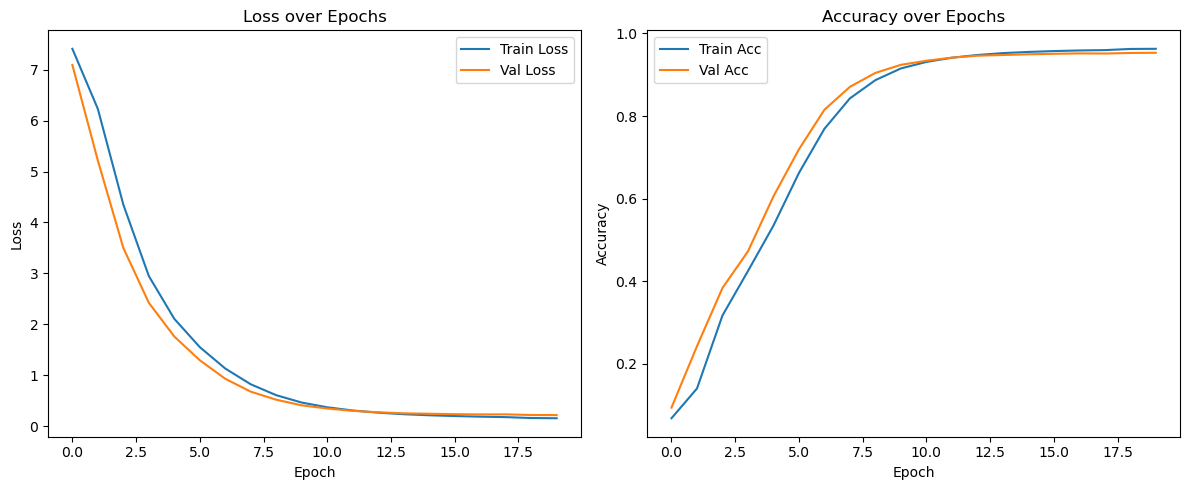

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def generate_text(model, sp, start_text, length=100, seq_length=32):
    input_ids = sp.encode_as_ids(start_text)
    generated_ids = input_ids[:]

    for _ in range(length):
        x = generated_ids[-seq_length:]
        if len(x) < seq_length:
            x = [0] * (seq_length - len(x)) + x

        x = np.array(x, dtype=np.int32)[None, :]  # ensure int32 for TensorFlow
        preds = model.predict(x, verbose=0)
        next_id = int(np.argmax(preds[0, -1]))  # make sure it's an int
        generated_ids.append(next_id)

    return sp.decode_ids([int(i) for i in generated_ids])


In [ ]:
print(generate_text(model, sp, "Jukolan", length=100))


Jukolan kristillinen veliparvi, ja sitten tapelkaamme kuin hullut sudet.--Huomatkaat: mies vihan vimmassa on verta-janoova peto, vaan ei ihminen; hän on umpisokea näkemään, mikä on oikeus ja kohtuus; ja kaikkein vähimmin voi hän vihansa vallassa suorittaa rakkauden asioita. Mutta jos nyt kuitenkin koettaisimme järjen kannalta katsella tätä seikkaa, joka saattoi veljet halkosilleen, niin luulen, että laita on näin. Tyttö ei taida meitä kaikkia rakastaa, yhtä ainoata vaan
